# Liquid-containing cloud hours across the Barrow region

`comparison_with_Genie_Obs.ipynb` collapses the domain to the single grid cell
holding the DOE ARM facility, because that is what the observations see. This
notebook keeps the latitude and longitude axes instead, so every cell in the
Barrow region gets its own answer — using the **identical** definitions: the
same `tcc` gate, the same fractional LWP/IWP boundaries, the same minimum water
paths, the same Oct 1 – Mar 31 window.

Domain: **70–80 °N, 165–150 °W**, 41 × 61 = 2,501 cells at 0.25°.

## The two quantities

| quantity | definition | units |
|---|---|---|
| hours | `n_liq / n_valid × season_hours` | h per season |
| fraction | `100 × n_liq / n_valid` | % of the season |

`n_liq` counts hours where the cell was overcast **and** liquid-containing —
that is, `LWP/(LWP+IWP) > 1 − ice_fraction_min`, merging liquid-only and
mixed-phase exactly as `season_phase_binary` does. The "no phase" residual goes
to ice-only, so the two categories sum to the overcast total.

The two carry the same information — `hours = fraction/100 × season_hours` — but
the window is 4,392 h in a leap-year season and 4,368 h otherwise, so the maps
are not a pure rescaling of one another *across* seasons.

## Why a ratio and not a raw count

Dividing by each cell's own valid hours before scaling to the nominal window
means a season with missing files is scaled **up** rather than counted short,
matching `to_hours_per_season` in the rest of the project. It also makes the
invariant exact per cell rather than approximate:

$$\text{liquid-containing fraction} \;\le\; \text{cloudy fraction}$$

because liquid-containing is a subset of overcast by construction and both share
the denominator. `check_invariants` asserts it at load time and raises on
violation — this is the property you asked for, and it is checked rather than
assumed.

## No area weighting, deliberately

Every number here is per cell, so no cos(latitude) weighting appears. That
weighting exists to average correctly *over* cells, and nothing in this notebook
averages over cells — applying it would be a bug. The one figure where it would
matter, a domain mean, is not drawn.

## Projection

North polar stereographic, not PlateCarree. Fifteen degrees of longitude is
about 570 km at 70 °N and 290 km at 80 °N, so a rectangular plot would misstate
the shape and area of everything in the domain.

---

## Every figure is drawn twice

Once with **all** data and once with the precipitation filter from
`comparison_with_Genie_Obs.ipynb` — `tp < 0.05 mm hr⁻¹`, unchanged. A
precipitating scene is removed from the *cloudy* population, so it stops
counting toward the liquid-containing hours and toward the overcast total
alike, and the phase categories still partition what remains.

Each figure carries a banner as the first line of its title — **ALL SKY** or
**PRECIPITATION FILTERED** — and the saved PNGs carry `_allsky_` or
`_noprecip0p05mmhr_` in their filenames, so neither the on-screen figure nor the
file on disk can be mistaken for the other variant.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import map_liquid_hours as mlh

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110

SAVE_DIR = Path("figures/liquid_maps")

## Load

The same inputs as `comparison_with_Genie_Obs.ipynb`. The parser is *shared* with
`plot_lwp_histogram_by_surface_class`, so "the same inputs" is literal rather
than a claim about two parallel implementations.

In [2]:
# Shared by every run below, so the maps, the class panels and the two
# precipitation variants cannot drift apart.
MAP_SETTINGS = dict(
    region="barrow",
    years=tuple(range(2014, 2025)),   # season START years
    season_start=(10, 1),
    season_end=(3, 31),

    phase_mode="fraction",
    liquid_fraction_min=0.90,         # LWP/CWP at or above this = liquid only
    ice_fraction_min=0.850,           # IWP/CWP at or above this = ice only

    min_lwp=0.01,                     # g m-2
    min_iwp=0.01,                     # g m-2

    min_cloud_fraction=0.95,
    lsm_tol=0.01,
    storage="local",
)

# The precipitation filter from comparison_with_Genie_Obs.ipynb, unchanged.
PRECIP_SETTINGS = dict(no_precip=True, precip_var="rate",
                      precip_rate_max=0.05)   # mm hr-1

M_all = mlh.prepare_maps(**MAP_SETTINGS)                      # all sky
M_np  = mlh.prepare_maps(**MAP_SETTINGS, **PRECIP_SETTINGS)   # filtered

# Every figure below is drawn once per entry, and each carries a banner
# naming its setting, so no figure can be mistaken for the other variant.
MAP_RUNS = [("all sky", M_all), ("precipitation filtered", M_np)]

removed = 1.0 - M_np.counts["cloudy"].sum() / M_all.counts["cloudy"].sum()
print(f"\nthe filter removes {100 * removed:.1f}% of overcast cell-hours "
      f"across the domain")


  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0%  (common year)
    2019/2020: 100.0%
    2020/2021: 100.0%  (common year)
    2021/2022: 100.0%  (common year)
    2022/2023: 100.0%  (common year)
    2023/2024: 100.0%
    2024/2025: 100.0%  (common year)
    2025/2026: 100.0%  (common year)

  Reading 11 season(s) on the native 41 x 61 grid: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]



  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0%
    2016/2017: 100.0%  (common year)
    2017/2018: 100.0%  (common year)
    2018/2019: 100.0%  (common year)
    2019/2020: 100.0%
    2020/2021: 100.0%  (common year)
    2021/2022: 100.0%  (common year)
    2022/2023: 100.0%  (common year)
    2023/2024: 100.0%
    2024/2025: 100.0%  (common year)
    2025/2026: 100.0%  (common year)

  Reading 11 season(s) on the native 41 x 61 grid: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]



the filter removes 14.0% of overcast cell-hours across the domain


### The numbers, and the tie back to the single-cell notebook

The `ARM h` column must reproduce the liquid-containing hours in
`comparison_with_Genie_Obs.ipynb` for the same settings. That agreement is what
makes these maps trustworthy rather than merely plausible — the map and the
single-cell analysis are separate code paths over the same archive.

In [3]:
for tag, Mi in MAP_RUNS:
    mlh.print_map_report(Mi)
    print()

*** ALL SKY — no precipitation filter ***
barrow region   |   70.00-80.00 N, -165.00--150.00 E   |   41 x 61 cells
season window 4,368-4,392 h   |   ARM cell (71.25 N, -156.50 E)

season      window     min h     med h     max h     ARM h     med %     ARM %  ARM cld%
2014/15      4,368     1,242     1,717     2,698     2,059     39.3%     47.1%     74.6%
2015/16      4,392     1,184     1,635     3,208     2,509     37.2%     57.1%     78.4%
2016/17      4,368     1,026     1,778     2,175     1,619     40.7%     37.1%     66.2%
2017/18      4,368     1,332     1,910     2,275     1,900     43.7%     43.5%     69.4%
2018/19      4,368     1,161     1,524     2,260     1,642     34.9%     37.6%     67.2%
2019/20      4,392       841     1,492     1,721     1,218     34.0%     27.7%     52.7%
2020/21      4,368     1,026     1,381     2,051     1,561     31.6%     35.7%     66.5%
2021/22      4,368       995     1,626     1,989     1,393     37.2%     31.9%     58.6%
2022/23      4,368 

## 1. Total hours per season, one panel per season

Shared colour scale across panels. Per-panel scales would make every season look
alike and hide the interannual range, which is the only thing a multi-season
figure is for.

The red star marks the ARM cell.

  -> figures/liquid_maps/barrow_map_hours_by_season_allsky_mean2014-2024.png


  -> figures/liquid_maps/barrow_map_hours_by_season_noprecip0p05mmhr_mean2014-2024.png


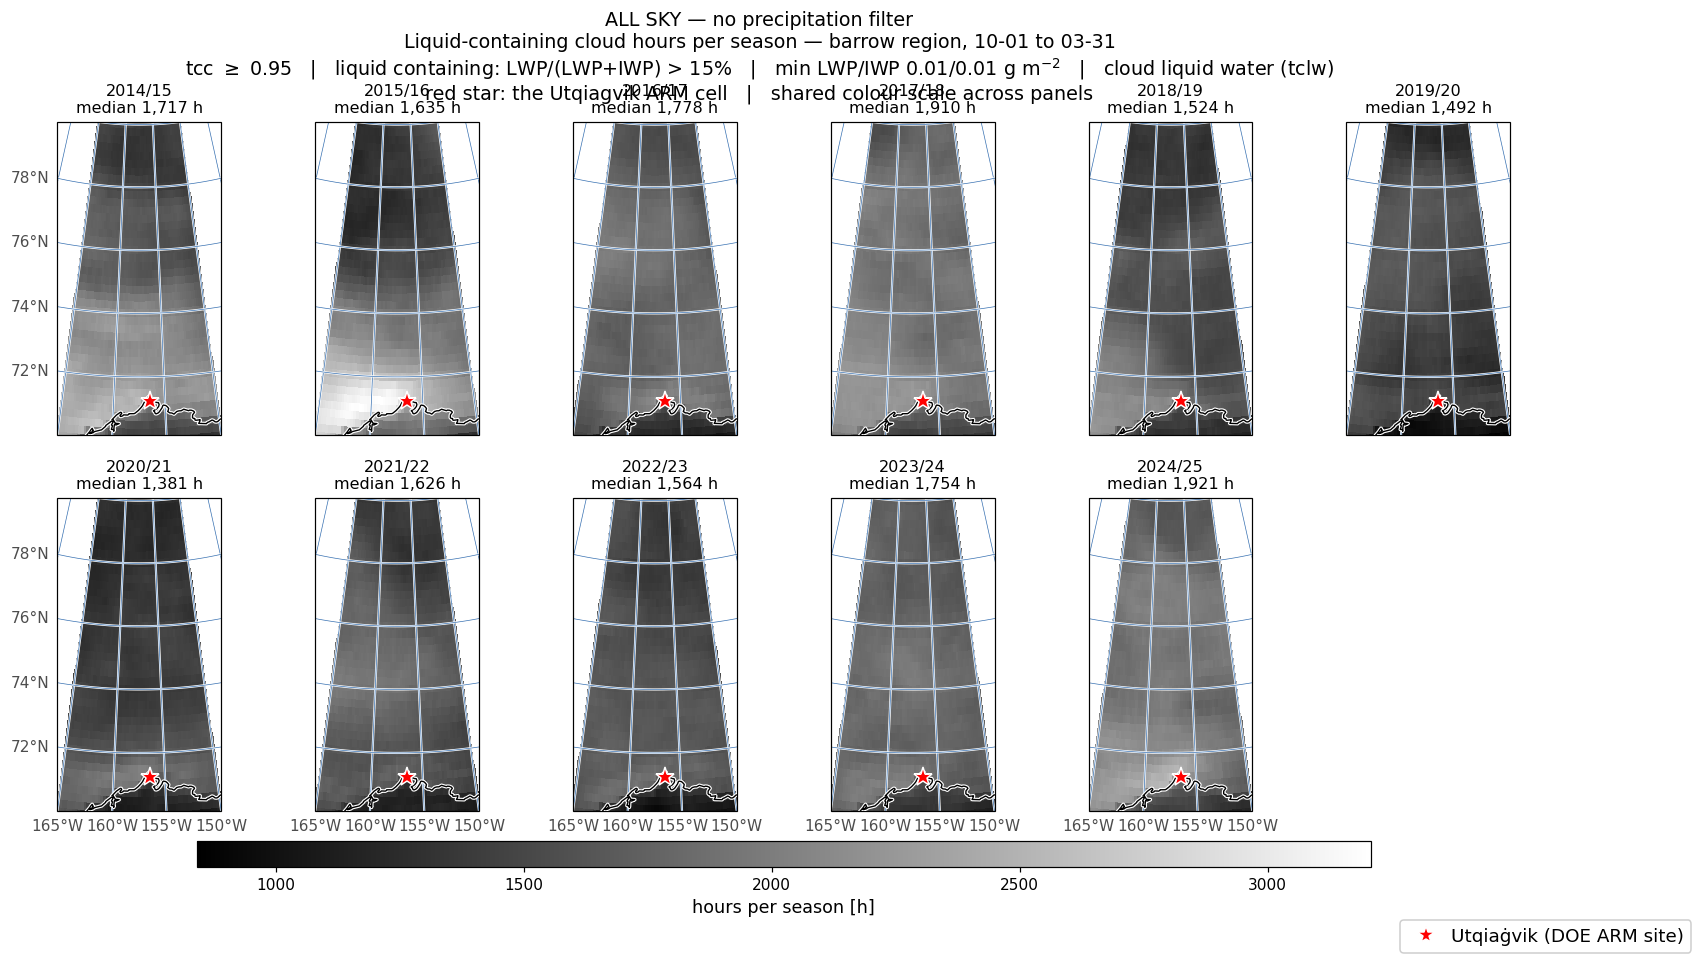

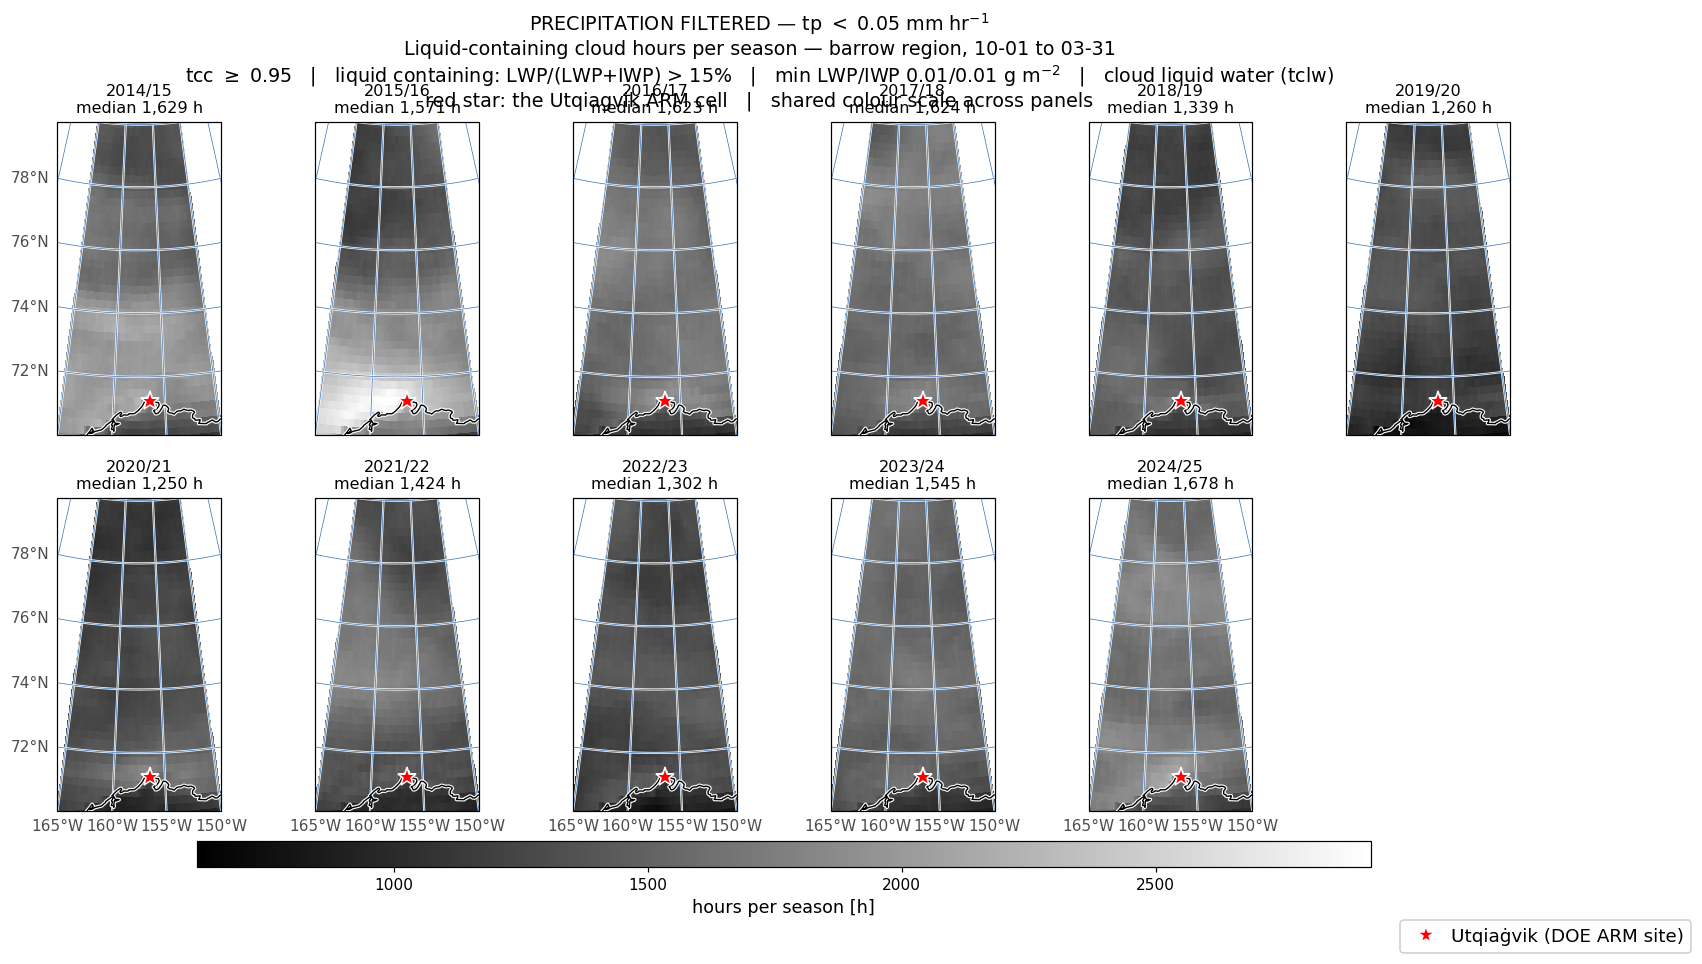

In [4]:
for tag, Mi in MAP_RUNS:
    mlh.fig_season_panels(Mi, quantity="hours", out_dir=SAVE_DIR)

## 2. Fraction of the season, one panel per season

The same hours divided by each season's own window length, as a percentage. By
construction this is ≤ the overcast fraction of the same cell — asserted at load
time.

  -> figures/liquid_maps/barrow_map_fraction_by_season_allsky_mean2014-2024.png


  -> figures/liquid_maps/barrow_map_fraction_by_season_noprecip0p05mmhr_mean2014-2024.png


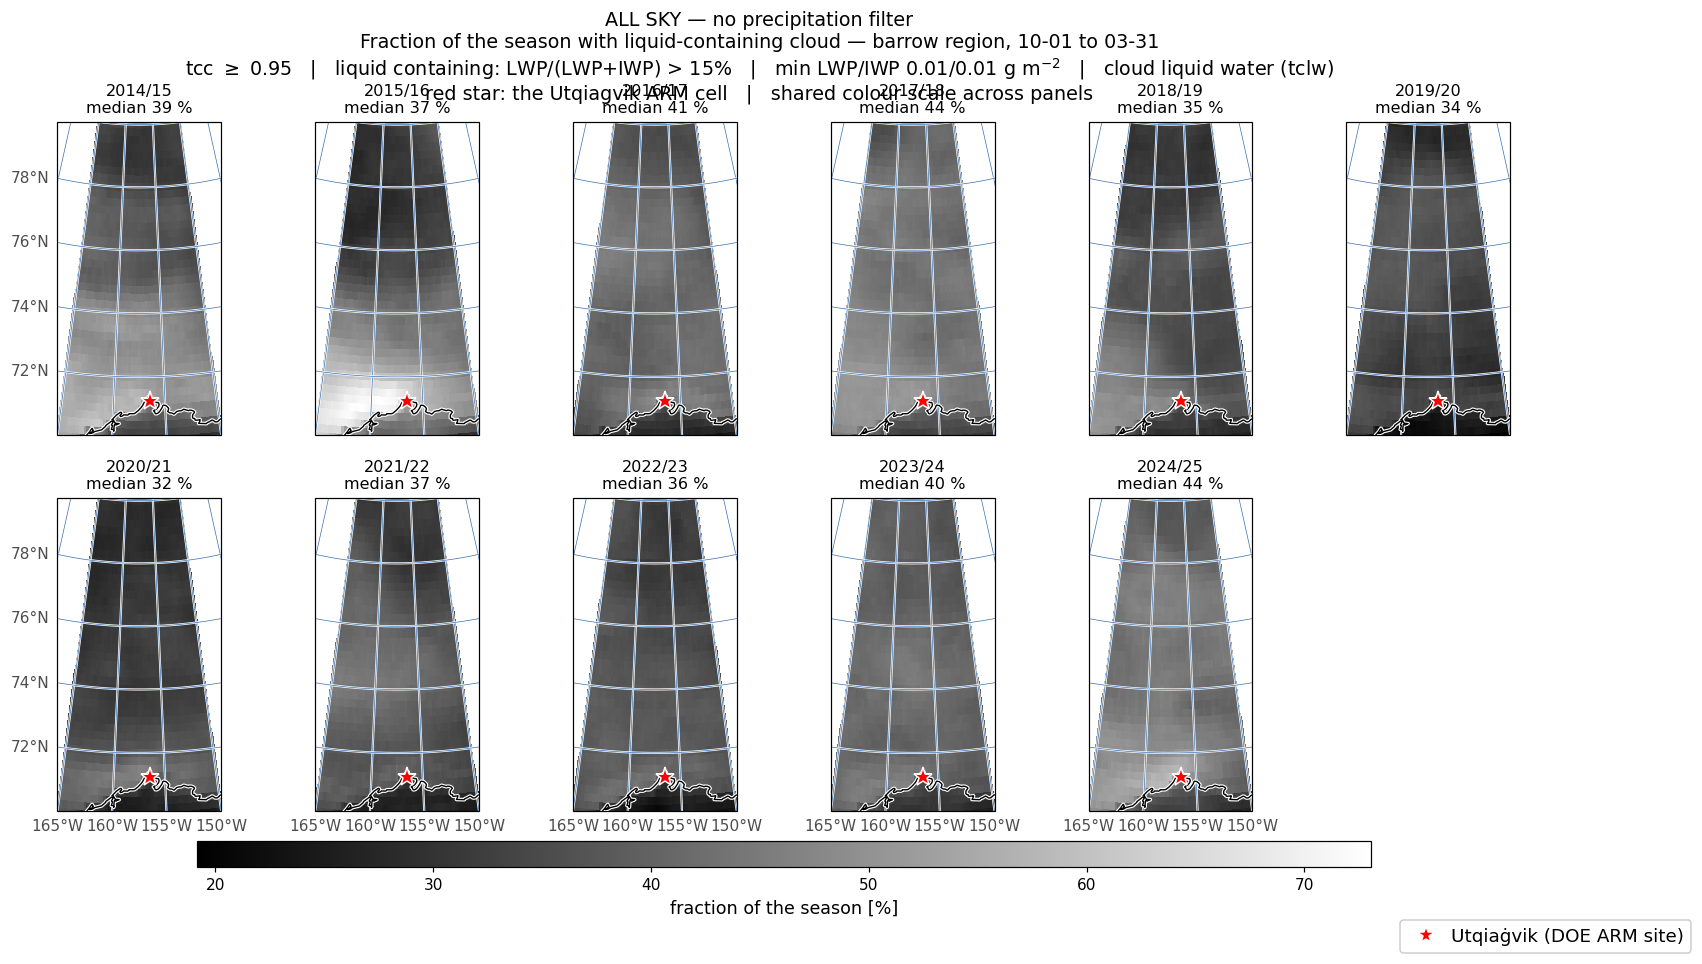

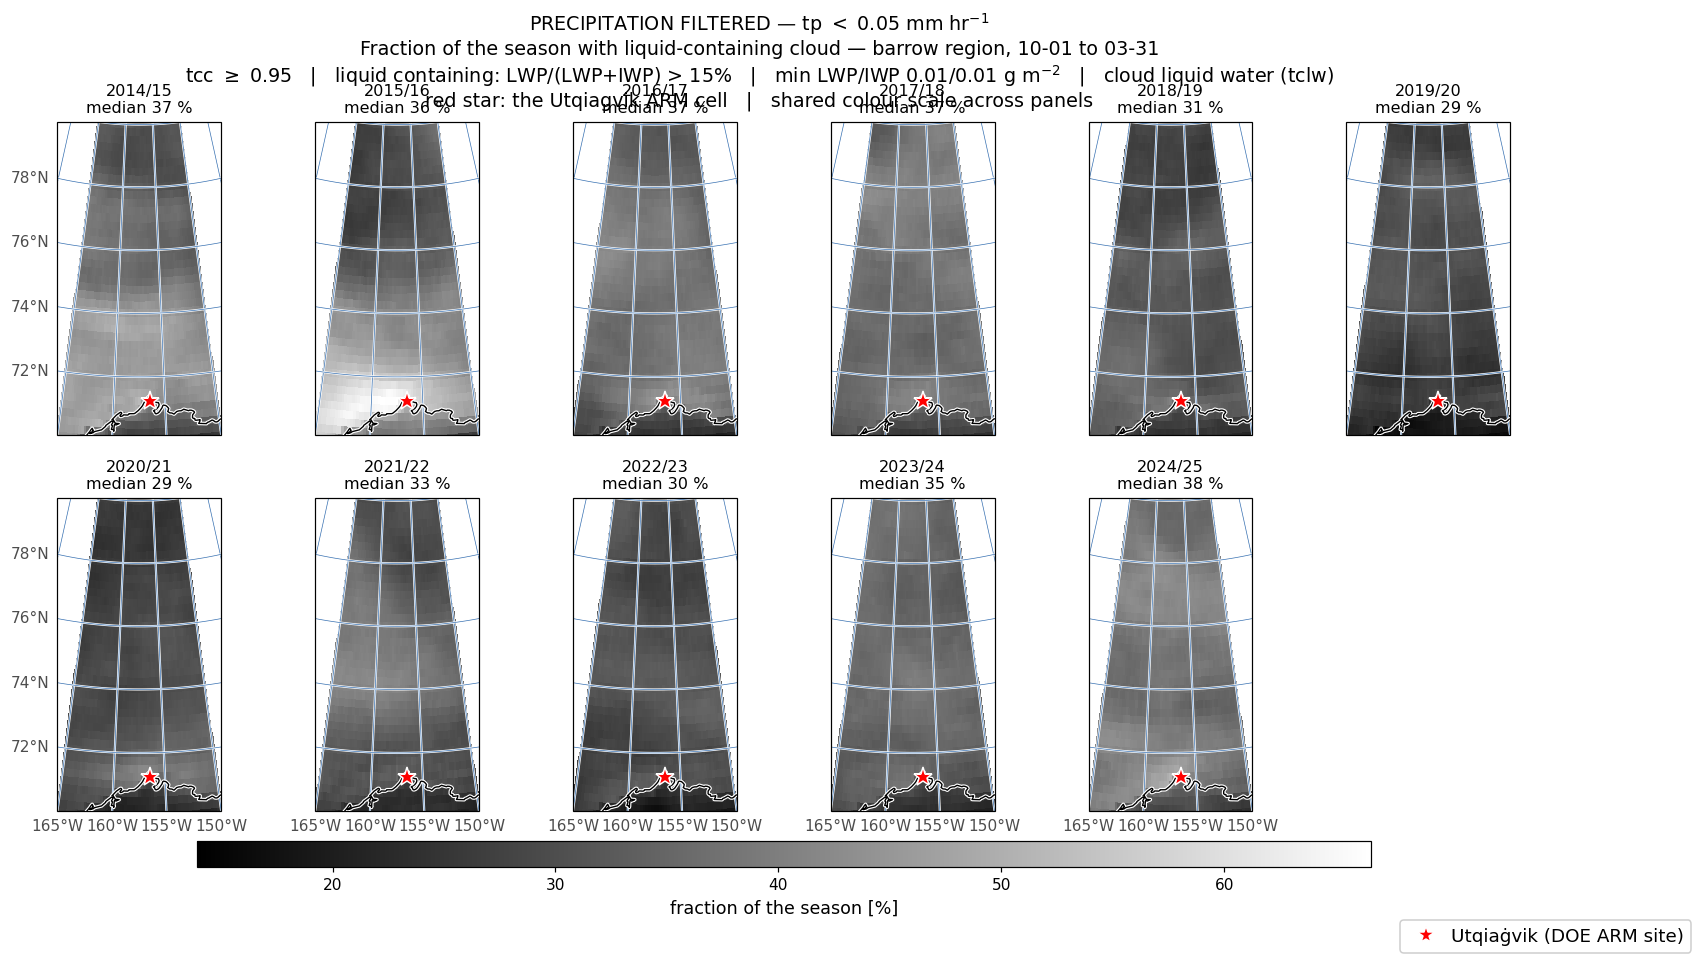

In [5]:
for tag, Mi in MAP_RUNS:
    mlh.fig_season_panels(Mi, quantity="fraction", out_dir=SAVE_DIR)

## 3. Mean total hours across all seasons

Unweighted mean over seasons, so every season counts once regardless of how many
hours of it the archive holds. `--min-season-coverage` exists to keep a badly
incomplete season out of this average.

  -> figures/liquid_maps/barrow_map_hours_season_mean_allsky_mean2014-2024.png


  -> figures/liquid_maps/barrow_map_hours_season_mean_noprecip0p05mmhr_mean2014-2024.png


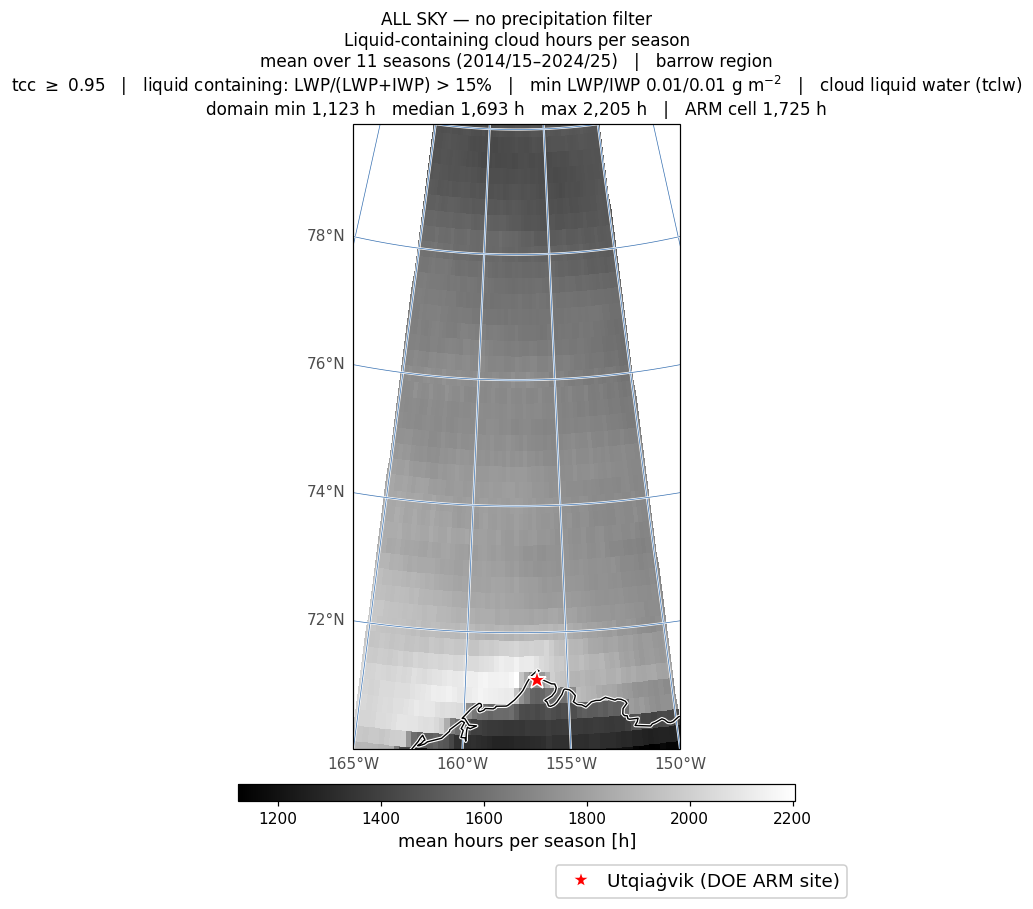

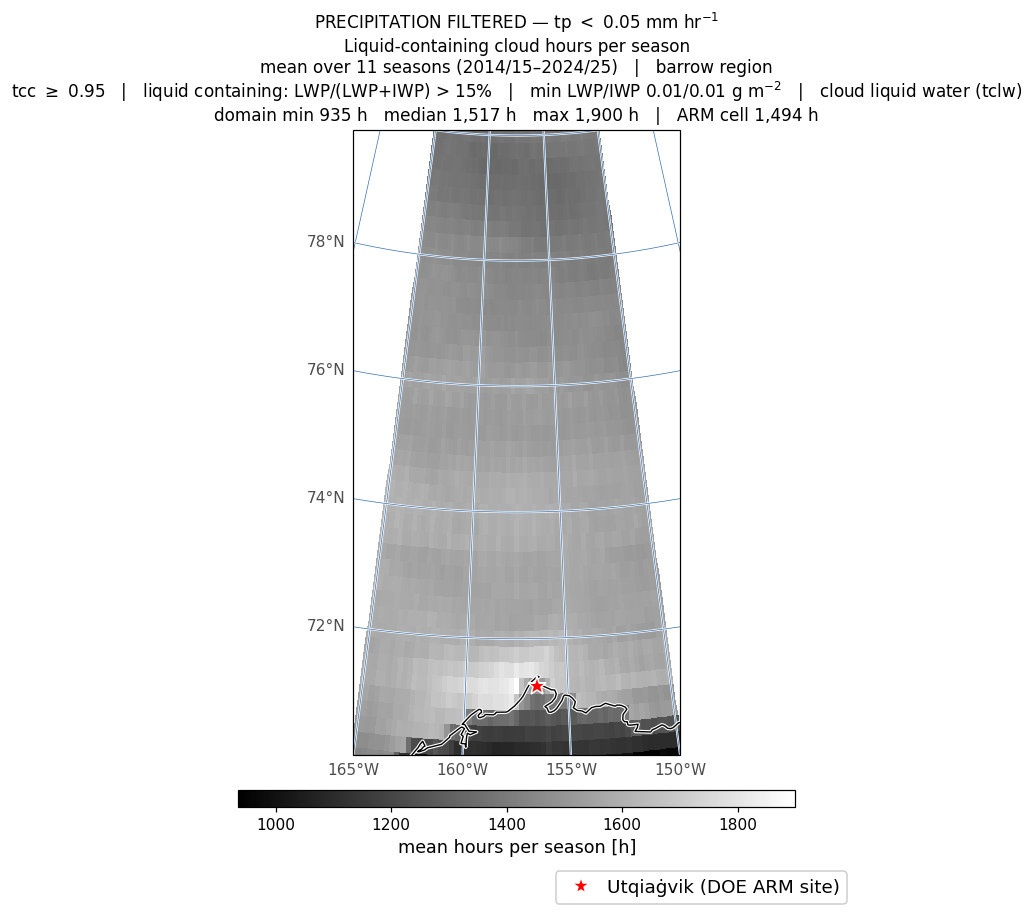

In [6]:
for tag, Mi in MAP_RUNS:
    mlh.fig_season_mean(Mi, quantity="hours", out_dir=SAVE_DIR)

## 4. Mean fraction of the season across all seasons

  -> figures/liquid_maps/barrow_map_fraction_season_mean_allsky_mean2014-2024.png


  -> figures/liquid_maps/barrow_map_fraction_season_mean_noprecip0p05mmhr_mean2014-2024.png


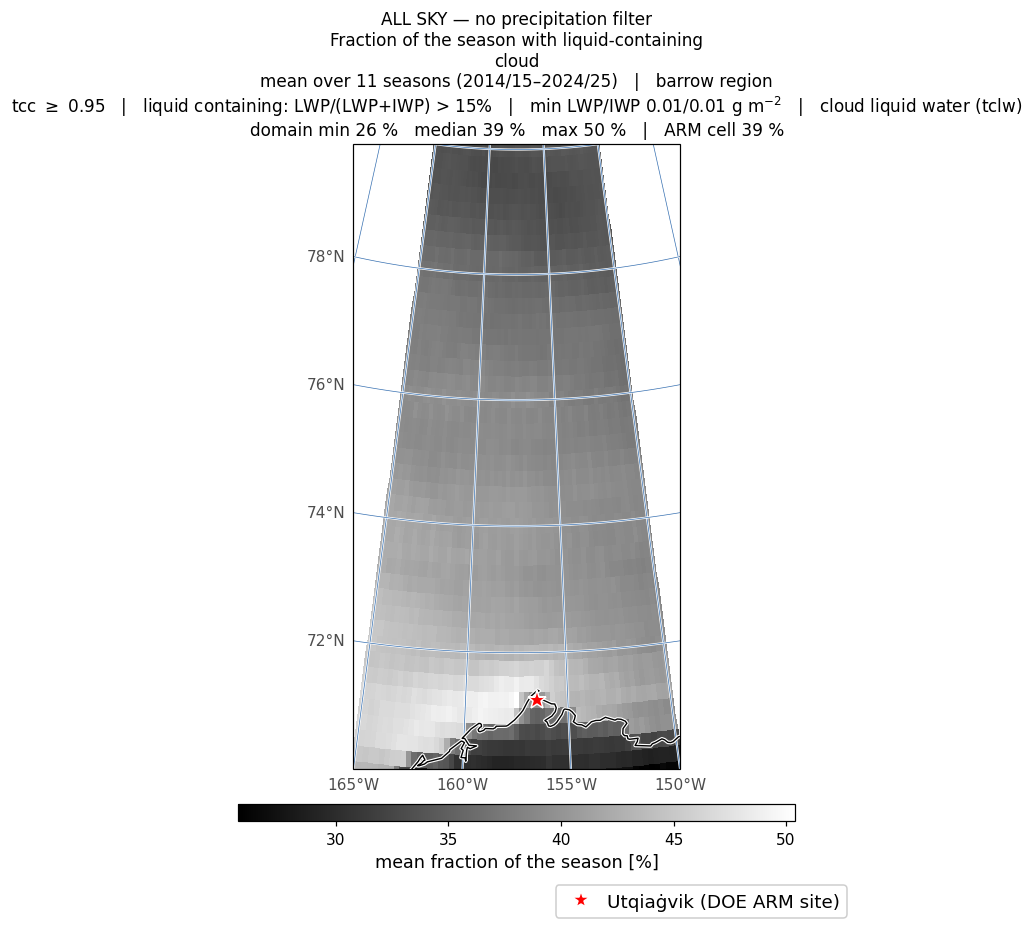

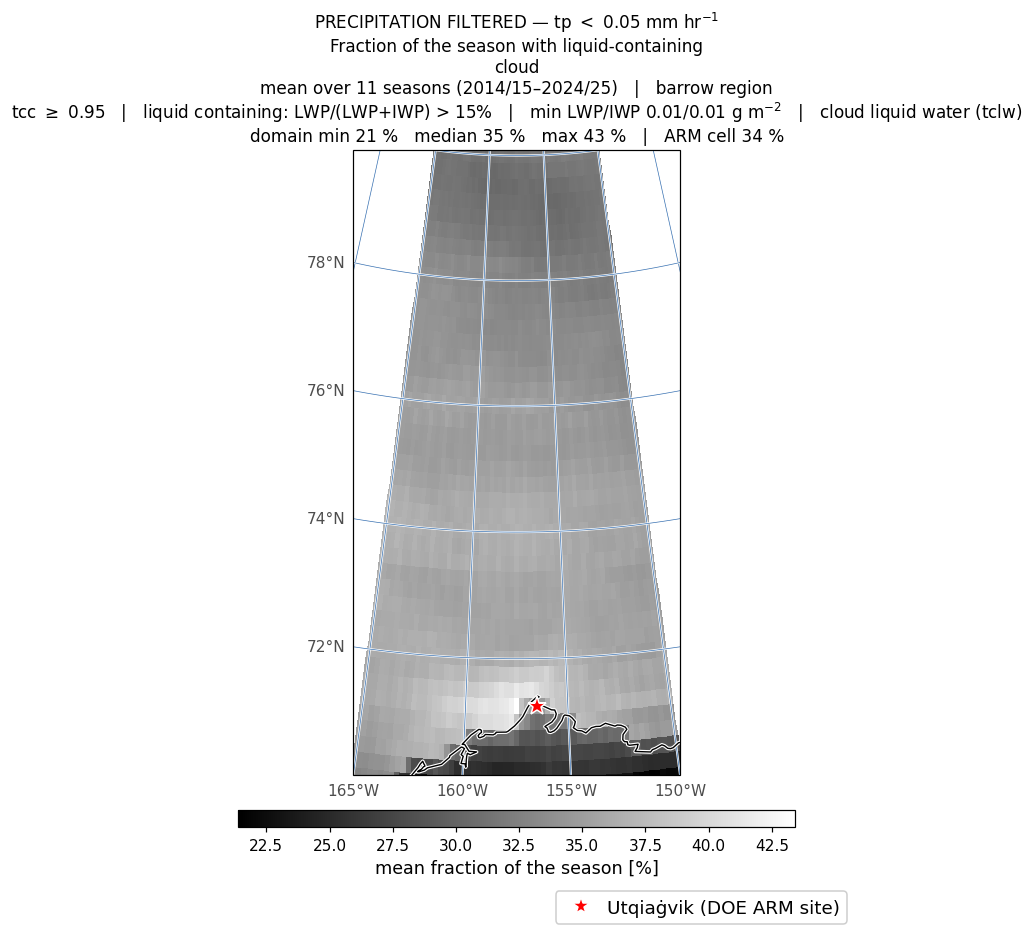

In [7]:
for tag, Mi in MAP_RUNS:
    mlh.fig_season_mean(Mi, quantity="fraction", out_dir=SAVE_DIR)

## 5. For reference — mean overcast fraction

Not requested, but it is the ceiling the liquid-containing fraction sits under,
and the two maps together separate *how often it is cloudy* from *what phase the
cloud is* — which are the two questions that can fail independently.

  -> figures/liquid_maps/barrow_map_cloudy_season_mean_allsky_mean2014-2024.png
all sky: domain median overcast 73.3%   liquid containing 38.7%   -> liquid share of cloudy time 52.8%


  -> figures/liquid_maps/barrow_map_cloudy_season_mean_noprecip0p05mmhr_mean2014-2024.png
precipitation filtered: domain median overcast 63.5%   liquid containing 34.7%   -> liquid share of cloudy time 54.6%


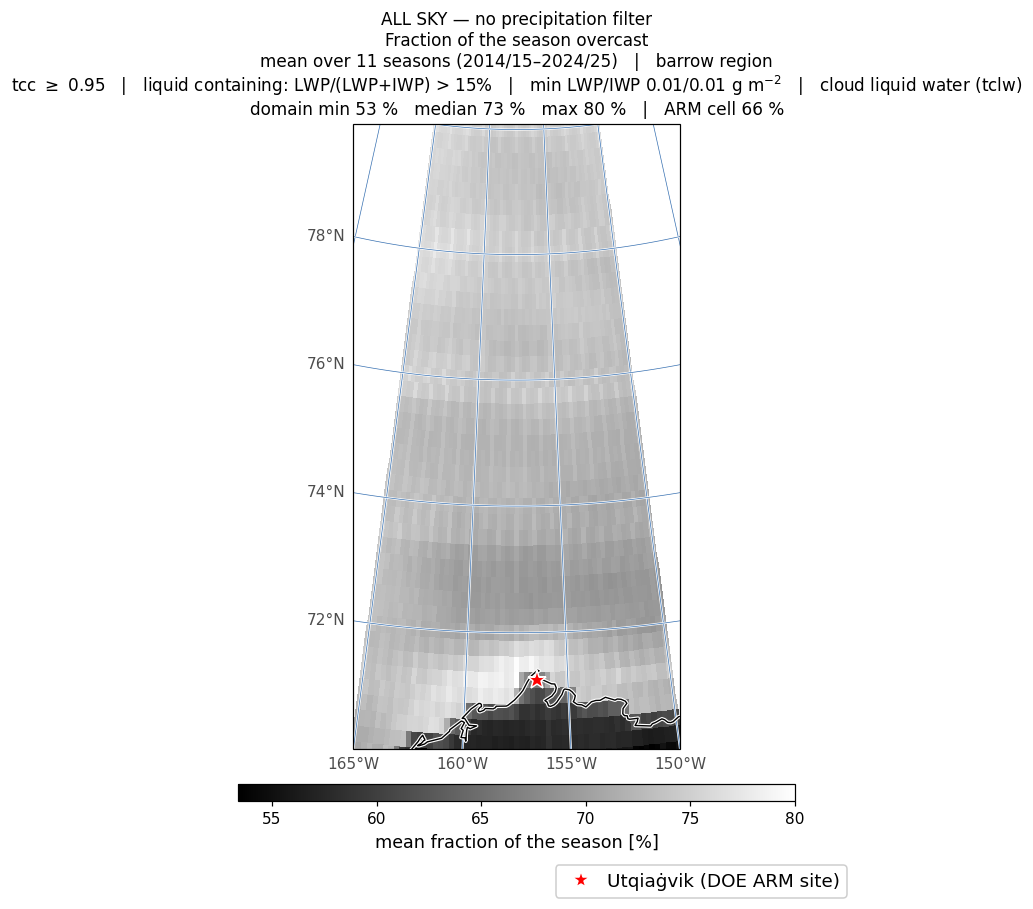

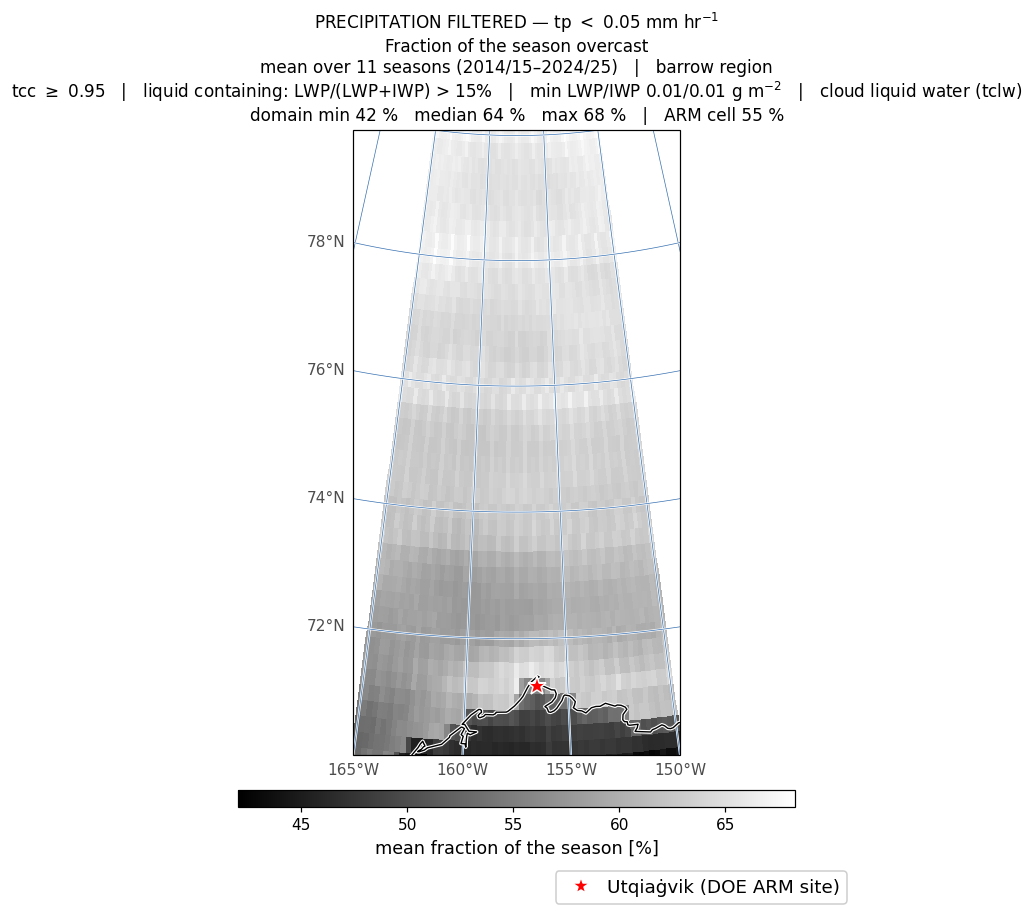

In [8]:
for tag, Mi in MAP_RUNS:
    mlh.fig_season_mean(Mi, quantity="cloudy", out_dir=SAVE_DIR)
    print(f"{tag}: domain median overcast "
          f"{np.nanmedian(Mi.cloudy_pct_mean):.1f}%   liquid containing "
          f"{np.nanmedian(Mi.fraction_pct_mean):.1f}%   -> liquid share of "
          f"cloudy time "
          f"{100 * np.nanmedian(Mi.fraction_pct_mean) / np.nanmedian(Mi.cloudy_pct_mean):.1f}%")

## Reading these maps

Three things worth separating:

1. **Land against ocean.** The southern edge of the domain is the Alaskan north
   slope; north of the coast is the Beaufort/Chukchi sea, seasonally ice-covered.
   A sharp coastal gradient is physical — open water and thin ice supply moisture
   that land and thick ice do not — and `plot_surface_class_timeseries.py` splits
   this by surface class if you want it quantified rather than eyeballed.
2. **The meridional gradient.** Liquid-containing cloud should thin northward as
   the atmosphere cools and the ice thickens. If it does not, the ice-fraction
   boundary rather than the physics may be doing the work.
3. **Is the ARM cell representative?** This is the question the map answers that
   the single-cell notebook cannot. If the ARM cell sits far from the domain
   median, then comparing ERA5 there against Genie's observations is testing a
   local value, and the regional picture would differ.

## 5b. How often, and how much liquid — side by side

The mean liquid-containing fraction beside the mean LWP of those clouds. The two
need not vary together: a cell can have liquid cloud often but thin, or rarely
but thick, and the pair separates the two.

The LWP panel is the mean over **every liquid-containing hour** across seasons —
weighted by each season's hour count, so it is one mean over all such hours
rather than a mean of season means. It is undefined where a cell never had
liquid-containing cloud, which does not happen in this domain.

Both maps now carry latitude/longitude tick marks and a margin legend naming the
red star.

  -> figures/liquid_maps/barrow_map_fraction_and_lwp_allsky_mean2014-2024.png


  -> figures/liquid_maps/barrow_map_fraction_and_lwp_noprecip0p05mmhr_mean2014-2024.png


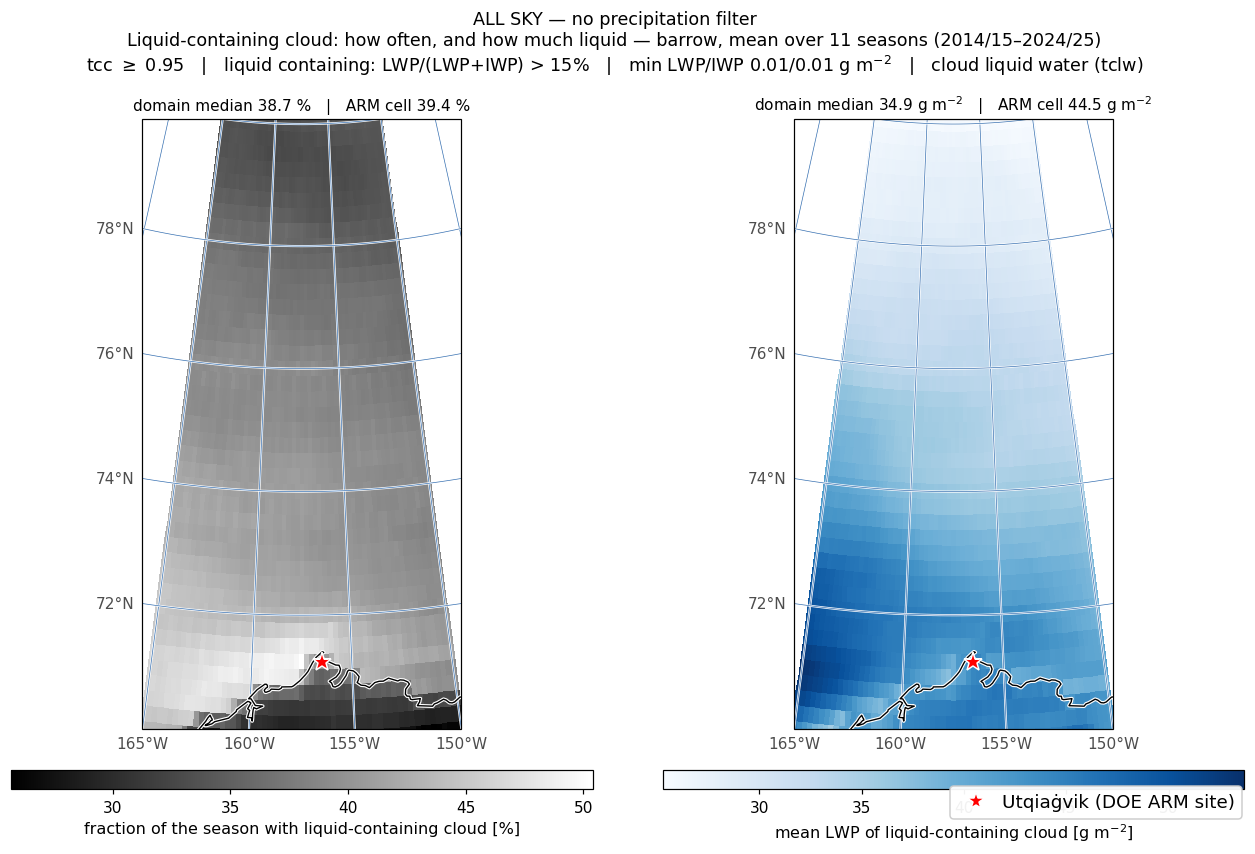

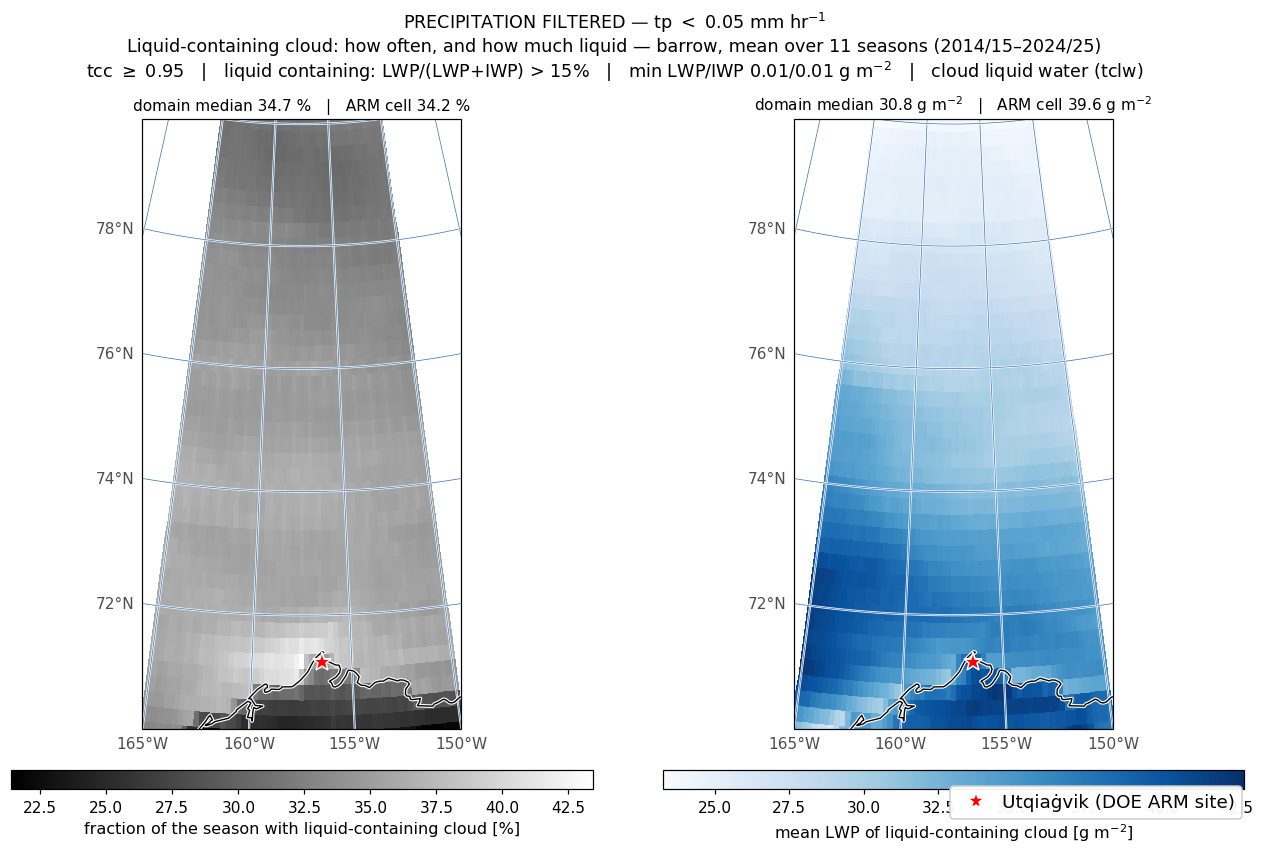

In [9]:
for tag, Mi in MAP_RUNS:
    mlh.fig_fraction_and_lwp(Mi, out_dir=SAVE_DIR)

## 5c. One season month by month, with the ice edge

The construction from `plot_monthly_flux_maps.py` (the turbulent-flux maps in
`era5_aws_analysis.ipynb`), applied to liquid cloud: the same region, October
through March, with the monthly-mean sea ice concentration contoured on every
panel — **dashed at 0.05**, where open water gives way to ice, and **solid at
0.95**, where full pack ice begins. Those are the concentrations this project's
surface classes are cut at, so the lines are the boundaries between open ocean,
marginal ice zone and sea ice as the season freezes up.

**Top row:** fraction of the month with liquid-containing cloud, per cell, on
the same black-to-white scale as the season maps — a partly sampled month reads
as a rate, not a shortfall. **Bottom row:** mean LWP over those hours, on the
white-to-blue scale. Each row has one colour scale across its six months.

Line art is chosen to read on every background both maps produce: gridlines
blue with a white halo, ice contours orange with a white halo (complementary to
the blue map, unlike anything on the grey one), coastline black with a halo.
The same three styles are used on every map in this notebook.

Shown for **2024/25**; any season in the run can be passed. The per-month
accumulators reproduce the season totals to machine precision (checked at
build), so these panels and the season maps above are the same hours.

  -> figures/liquid_maps/barrow_map_monthly_2024_allsky_mean2014-2024.png


  -> figures/liquid_maps/barrow_map_monthly_2024_noprecip0p05mmhr_mean2014-2024.png


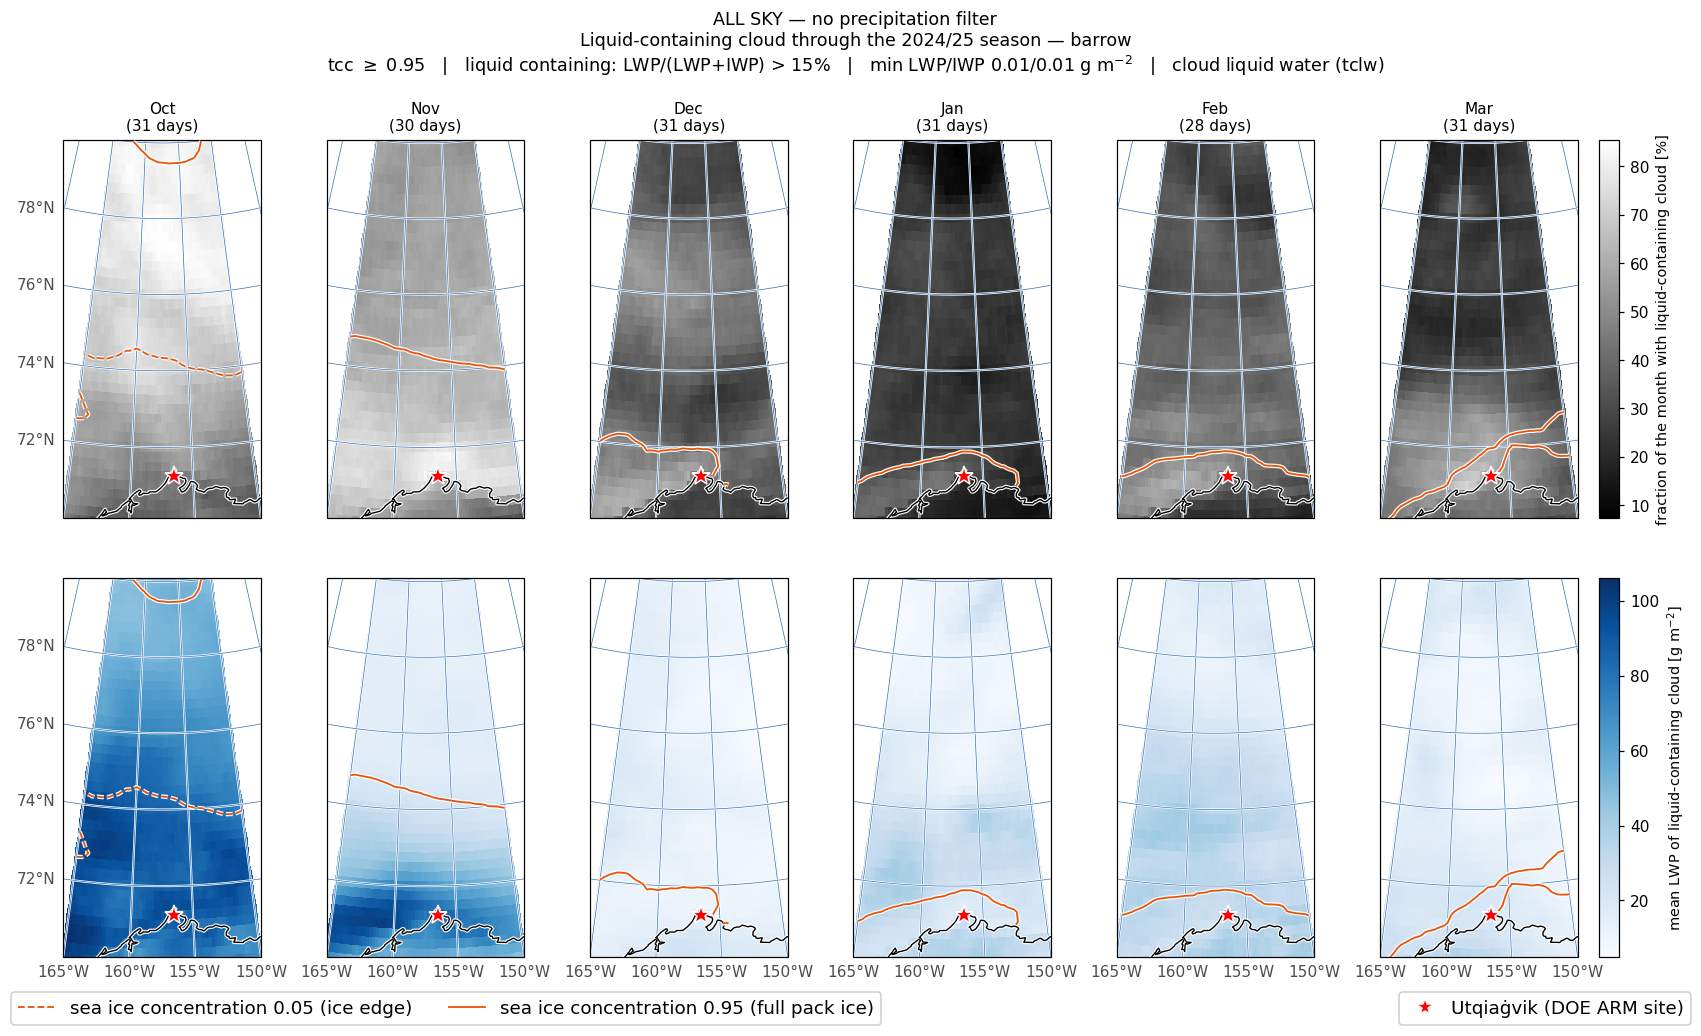

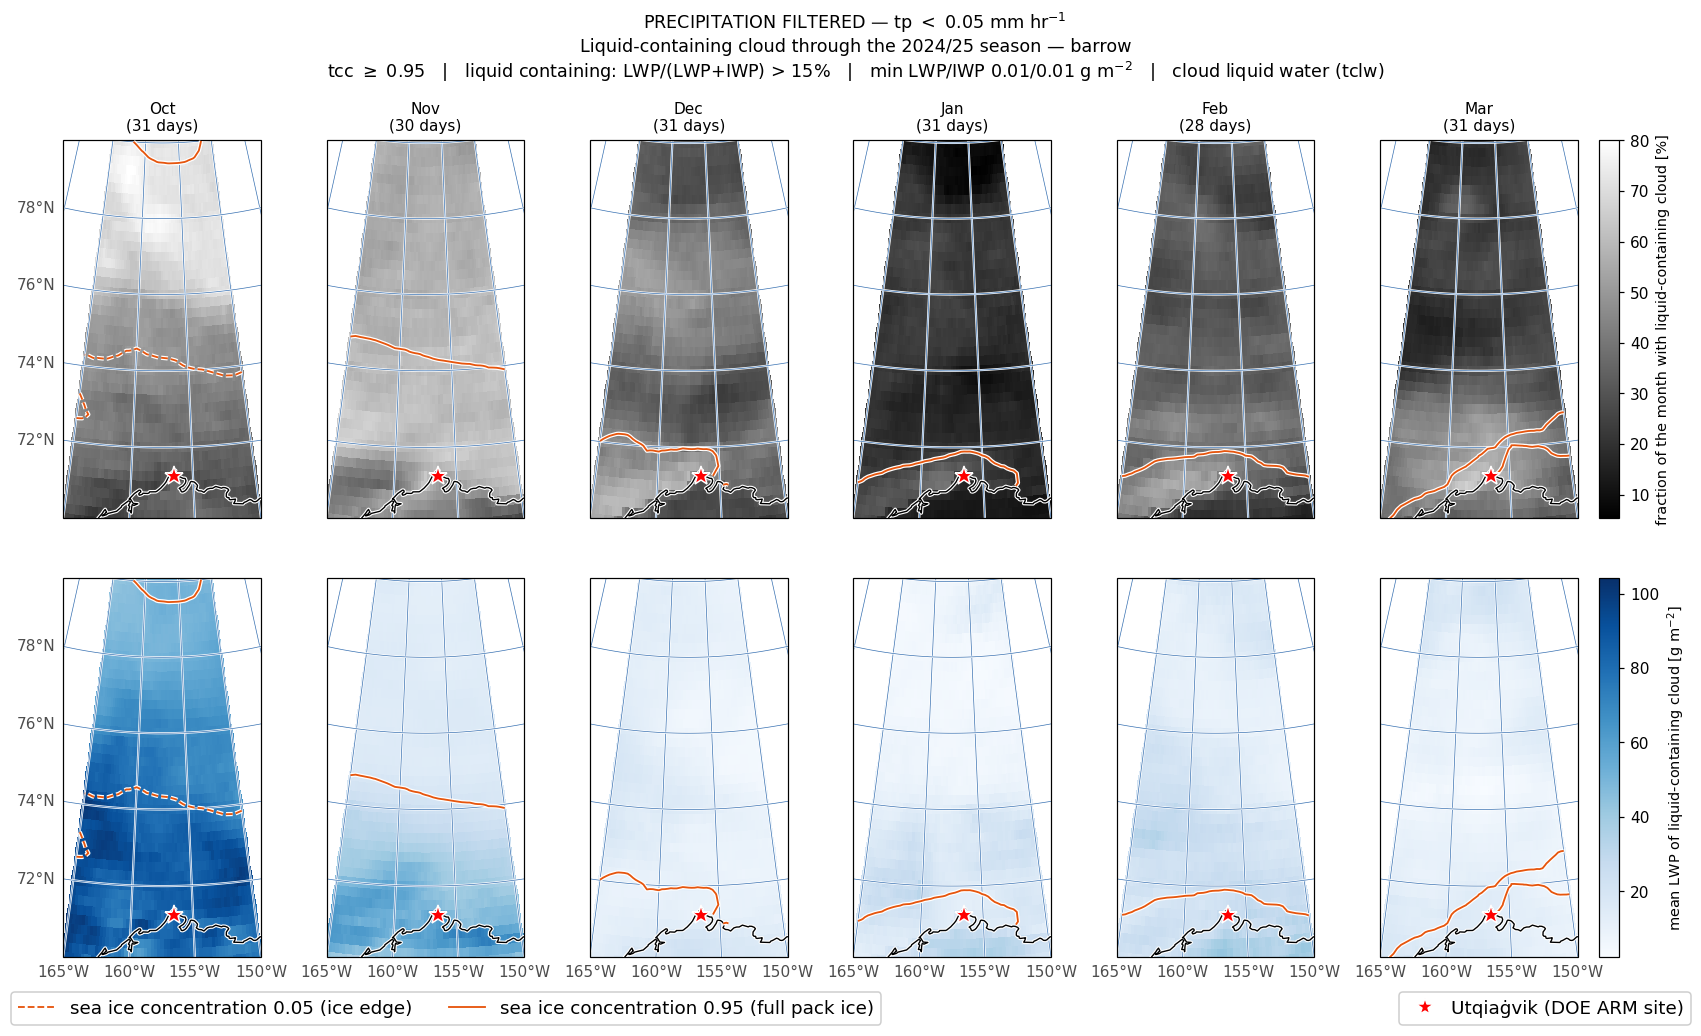

In [10]:
SEASON = 2024      # season start year; any of M_all.used

for tag, Mi in MAP_RUNS:
    mlh.fig_season_monthly_maps(Mi, season=SEASON, out_dir=SAVE_DIR)

---

# 6. By surface class

The maps show *where*; this section groups those cells into the five surface
classes from `plot_surface_class_timeseries.ipynb` — land, coastal, open ocean,
marginal ice zone, sea ice — plus the single ARM cell, and asks how the
liquid-containing fraction differs between them.

## The averaging scheme

Each bar is

$$\text{fraction}(s,\,c)=100\times\frac{\text{liquid-containing cell-hours in class } c}{\text{valid cell-hours class } c \text{ actually occupied}}$$

a **ratio of sums** over cell-hours — pool first, divide once — not a mean of
per-cell fractions. That distinction is not cosmetic here.

**Why not a mean of per-cell fractions.** Three of the five classes are defined
by sea ice concentration, so **class membership moves**: a cell is open ocean in
October and sea ice in February. A per-cell fraction needs a denominator of "the
hours *that* cell spent in *this* class", and averaging those fractions across
cells would give a cell present for 20 hours the same weight as one present for
2,000. Pooling cell-hours first weights each cell by how long it was actually in
the class — the only construction that stays correct while the ice edge
migrates.

This is the normalisation the rest of the project already uses, and the error it
avoids is large: multiplying a monthly occupancy fraction by the calendar month
instead reached a **1,595 h** discrepancy on this archive, a third of a season.

## Should the weighting be cos(latitude)? — yes, and here is why

Your instinct is right, and the two choices answer genuinely different
questions:

| weight | question it answers |
|---|---|
| `area` = cos φ | per unit **area** of the class — a randomly chosen km²-hour of pack ice |
| `uniform` | per **grid cell** of the class — a randomly chosen ERA5 cell-hour of pack ice |

They are not interchangeable **because the classes are latitude-structured**. A
0.25° cell covers about 264 km² at 70 °N but only 134 km² at 80 °N, and pack ice
sits at the northern end of this domain. Uniform weighting therefore counts a
northern ice cell as fully as a southern one covering twice the ground, which
inflates the northern contribution to exactly the classes that live there.

**Default is `area`.** "What fraction of the pack-ice *region* carried liquid
cloud" has a physical referent; a grid-cell count is an artefact of ERA5's grid
rather than a property of the Arctic.

But the size of the disagreement is an empirical question, not one to assert —
so the next cell measures it. The ARM row is the control: a single cell has no
interior cells to weight, so it must read exactly 0.00.

## One ambiguity in the request, resolved both ways

"the fraction of time … with liquid containing clouds **within a cloudy scene**"
can mean either the fraction of *all* season time, or the fraction of *cloudy*
time. The bars use **all season time**, matching sections 1–4 and the phrase
"fraction of time in that season". The conditional reading is shown too: the
dashed outline behind each bar is the overcast fraction, so the gap reads as
"cloudy but not liquid containing", and each panel header gives the
liquid-containing share of cloudy time explicitly.

In [11]:
import plot_lwp_histogram_by_surface_class as lwph
import plot_class_liquid_fractions as pcf

A_cls    = lwph.prepare(**MAP_SETTINGS)
A_cls_np = lwph.prepare(**MAP_SETTINGS, **PRECIP_SETTINGS)

# The weighting check is a methodological control, not a result, so it runs
# once on the all-sky data rather than twice.
A_cls_u = lwph.prepare(cell_weighting="uniform", **MAP_SETTINGS)
pcf.compare_weightings(A_cls, A_cls_u)

Liquid-bearing cloud hours by LWP and surface class


  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  Cell weight: area (cos latitude)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.85
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0

Liquid-bearing cloud hours by LWP and surface class


  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  Cell weight: area (cos latitude)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.85
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 100.0

Liquid-bearing cloud hours by LWP and surface class


  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : cloud liquid water (tclw)
  Cell weight: uniform (per grid cell)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.85
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016: 1

panel                   area-wtd   uniform     diff      rel
Land                      28.31%    28.31%   +0.00    +0.0%
Coastal (mixed)           34.52%    34.61%   +0.09    +0.3%
Open ocean                59.87%    60.10%   +0.23    +0.4%
Marginal ice zone         58.24%    59.09%   +0.85    +1.5%
Sea ice                   31.41%    31.43%   +0.03    +0.1%
Utqiagvik (ARM site)      39.44%    39.44%   +0.00    +0.0%

  A single grid cell has no interior cells to weight, so the ARM row must read
  exactly 0.00 -- it is the control on this table.


## 6.1 The six panels

Bar height is the fraction of the season window with a liquid-containing cloud
overhead; the dashed outline is the overcast fraction of the same class, so the
subset relation is visible rather than asserted. The dotted line is the record
mean.

Each panel header also carries the record-mean **supercooled** fraction, from an
otherwise identical run with `liquid_var="tcslw"`. `_check_comparable` raises if
anything but the liquid field differs between the two runs.

Caveat carried from `compare_supercooled_liquid.ipynb`: `tcslw` is a forecast
initialised at 06/18 UTC while `tclw` is the analysis, so part of the gap between
the two numbers is forecast error rather than thermodynamics. Both runs here use
all 24 hours, so they are at least on the same sample;
`cld.hours_for_lead(3)` restricts to short leads if you want the cleaner
comparison.

Liquid-bearing cloud hours by LWP and surface class


  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : supercooled liquid water (tcslw)
  Cell weight: area (cos latitude)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.85
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016

Liquid-bearing cloud hours by LWP and surface class


  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 108,120 time steps
  Season     : 10-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95
  Cloudy     : tcc >= 0.95
  Liquid     : supercooled liquid water (tcslw)
  Cell weight: area (cos latitude)
  Phase mode : fraction
  Categories : liquid only: LWP/CWP >= 0.9 | ice only: IWP/CWP >= 0.85 | mixed: the rest | CWP = LWP + IWP above 0.01/0.01 g m-2
               ice only: IWP/CWP >= 0.85
  LWP bins   : linear 0-600 in 24 | log 0.01-1000 in 12

  Seasons found (18), coverage of the 182-183-day window:
    1999/2000:  49.7%   (below --min-season-coverage)
    2000/2001: 100.0%  (common year)
    2001/2002:  50.5%  (common year)   (below --min-season-coverage)
    2011/2012: 100.0%
    2012/2013: 100.0%  (common year)
    2013/2014: 100.0%  (common year)
    2014/2015: 100.0%  (common year)
    2015/2016

  -> figures/liquid_maps/barrow_class_liquid_fraction_by_season_allsky_mean2014-2024.png


  -> figures/liquid_maps/barrow_class_liquid_fraction_by_season_noprecip0p05mmhr_mean2014-2024.png


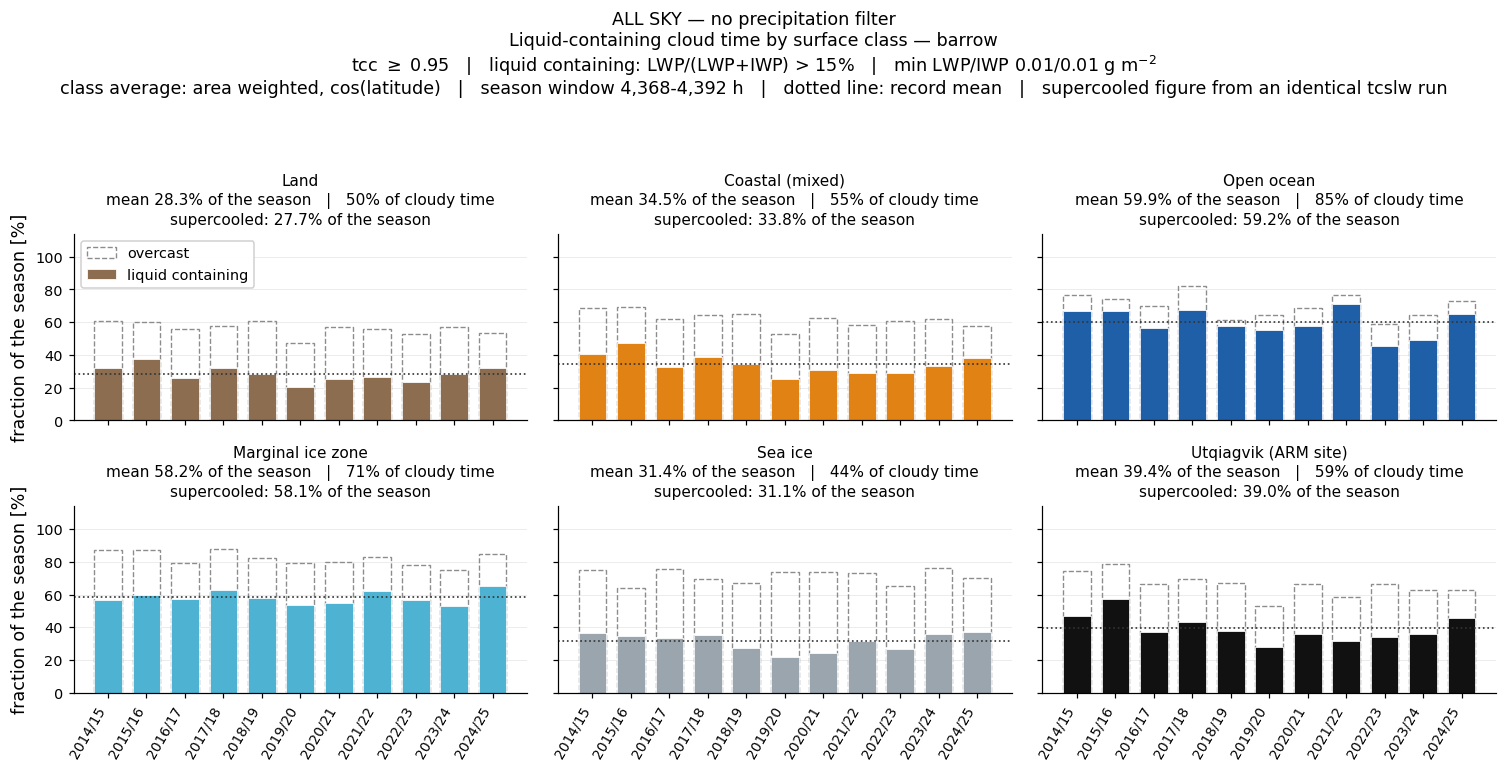

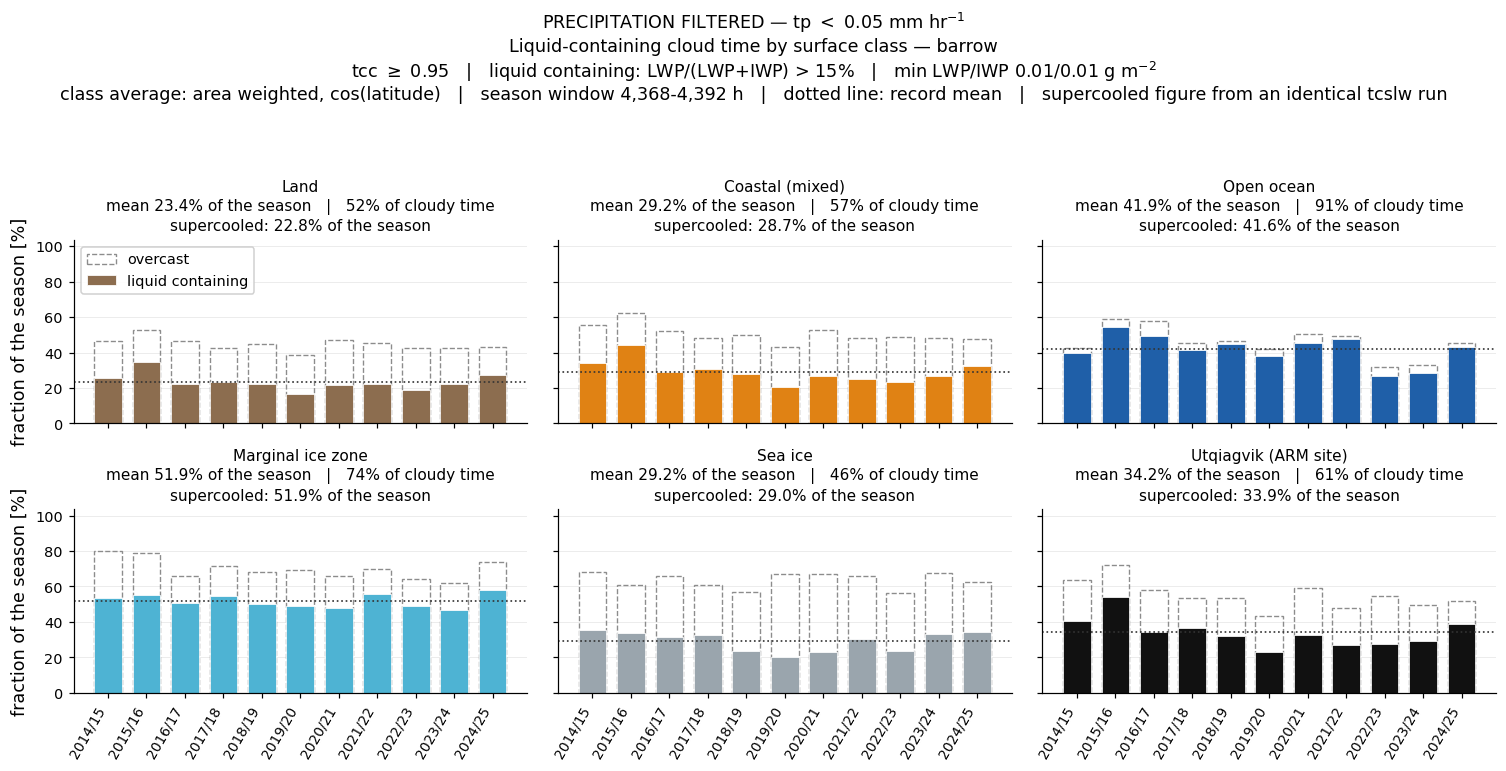

In [12]:
A_cls_sc    = lwph.prepare(liquid_var="tcslw", **MAP_SETTINGS)
A_cls_np_sc = lwph.prepare(liquid_var="tcslw", **MAP_SETTINGS,
                           **PRECIP_SETTINGS)

CLASS_RUNS = [("all sky", A_cls, A_cls_sc),
              ("precipitation filtered", A_cls_np, A_cls_np_sc)]

for tag, Ai, Ai_sc in CLASS_RUNS:
    pcf.fig_class_season_fractions(Ai, A_sc=Ai_sc, out_dir=SAVE_DIR)

## 6.2 The numbers

In [13]:
for tag, Ai, Ai_sc in CLASS_RUNS:
    pcf.print_class_report(Ai, A_sc=Ai_sc)
    print(f"  filter removed "
          f"{100 * Ai.col['precip_removed'] / Ai.col['cloudy_before_precip']:.1f}%"
          f" of overcast cell-hours\n" if Ai.args.no_precip else "")

*** ALL SKY — no precipitation filter ***
season               Land  Coastal (mixe     Open ocean  Marginal ice         Sea ice  Utqiagvik (AR
2014/15             31.8%          40.5%          67.0%          56.7%          36.7%          47.1%
2015/16             37.5%          47.5%          67.0%          59.7%          34.8%          57.1%
2016/17             25.8%          32.7%          56.4%          57.5%          33.7%          37.1%
2017/18             31.7%          38.5%          67.5%          63.1%          35.2%          43.5%
2018/19             28.4%          34.2%          57.4%          58.0%          27.1%          37.6%
2019/20             20.7%          25.5%          54.9%          53.7%          21.9%          27.7%
2020/21             25.3%          30.9%          57.5%          54.7%          24.3%          35.7%
2021/22             26.3%          29.2%          70.8%          62.4%          31.9%          31.9%
2022/23             23.5%          29.1%         